In [130]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

In [131]:
# Load Dataset
data = pd.read_csv('processed_stock_data.csv', parse_dates=['Date'], index_col='Date')

In [132]:
data.index = pd.to_datetime(data.index)

In [133]:
data = data.asfreq('D')

In [134]:
print(data.index.freq)

<Day>


In [135]:
# Select 'Close' price
series = data["Close"]

In [136]:
data.isnull().sum()

Open               908
High               908
Low                908
Close              908
Volume             908
50-day MA          957
200-day MA        1107
Close_diff         909
lag_1              909
lag_7              915
rolling_mean_7     914
rolling_std_7      914
dtype: int64

In [137]:
print(series.isna().sum())

908


In [138]:
len(data)

2919

In [139]:
series = series.dropna()

In [140]:
# Stationarity Check using ADF Test
adf_result = adfuller(series)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

ADF Statistic: 0.984317559130625
p-value: 0.9940976935123645


In [141]:
# Apply Differencing 
if adf_result[1] > 0.05:  # Non-stationary
    series = series.diff().dropna()
    print("Data differenced to achieve stationarity.")

Data differenced to achieve stationarity.


In [142]:
# Stationarity Check using ADF Test
adf_result = adfuller(series)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

ADF Statistic: -13.786088612366864
p-value: 9.106620961204917e-26


In [143]:
# Split Data into Train & Test
train_size = int(len(series) * 0.9)
train, test = series.iloc[:train_size], series.iloc[train_size:]

In [144]:
# Auto-ARIMA to Find Best Order
best_arima_order = auto_arima(train, seasonal=False, trace=True).order
print(f"Best ARIMA Order: {best_arima_order}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=7592.088, Time=3.59 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=7599.749, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=7601.176, Time=0.15 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=7601.117, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=7601.059, Time=0.76 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=7600.808, Time=0.44 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=2.85 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=3.51 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=7601.695, Time=0.57 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=7602.314, Time=0.94 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=7602.268, Time=0.92 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=4.97 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=7594.690, Time=4.88 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0]          
Total fit time: 23.820 seconds
Best ARIMA Order: (2, 0, 2)


In [145]:
# Train ARIMA Model
arima_model = ARIMA(train, order=best_arima_order)
arima_fit = arima_model.fit()
print(arima_fit.summary())

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1809
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -3791.118
Date:                Sat, 01 Mar 2025   AIC                           7594.236
Time:                        13:58:50   BIC                           7627.239
Sample:                             0   HQIC                          7606.416
                               - 1809                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0686      0.046      1.487      0.137      -0.022       0.159
ar.L1          1.2129      0.013     94.819      0.000       1.188       1.238
ar.L2         -0.9756      0.010    -98.238      0.0

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [146]:
# Forecast using ARIMA
arima_forecast = arima_fit.forecast(steps=len(test))

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [147]:
y_train_pred = arima_fit.predict()  
y_test_pred = arima_fit.forecast(steps=len(test))

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [148]:
mae = mean_absolute_error(test, y_test_pred)
rmse = mean_squared_error(test, y_test_pred, squared=False)

In [149]:
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

MAE: 2.37
RMSE: 3.16


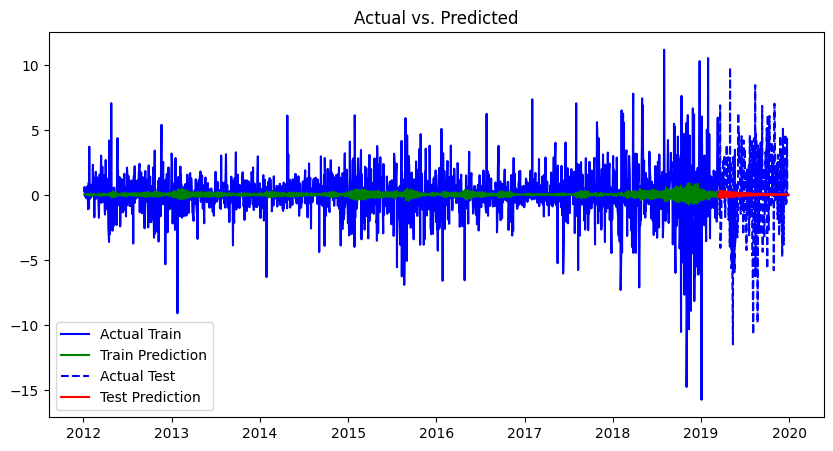

In [150]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Actual Train", color="blue")  
plt.plot(train.index, y_train_pred, label="Train Prediction", color="green")

plt.plot(test.index, test, label="Actual Test", color="blue", linestyle="dashed")
plt.plot(test.index, y_test_pred, label="Test Prediction", color="red")  # ✅ FIXED!

plt.legend()
plt.title("Actual vs. Predicted")
plt.show()

In [151]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline 1: Using the previous day's price as prediction
y_baseline_prev = test.shift(1).dropna()  # Shift actual test values by 1 day
baseline_mae_prev = mean_absolute_error(test[1:], y_baseline_prev)
baseline_rmse_prev = np.sqrt(mean_squared_error(test[1:], y_baseline_prev))

# Baseline 2: Using mean of training data as prediction
y_baseline_mean = np.full_like(test, train.mean())
baseline_mae_mean = mean_absolute_error(test, y_baseline_mean)
baseline_rmse_mean = np.sqrt(mean_squared_error(test, y_baseline_mean))

print(f"Baseline (Previous Day) - MAE: {baseline_mae_prev:.2f}, RMSE: {baseline_rmse_prev:.2f}")
print(f"Baseline (Mean) - MAE: {baseline_mae_mean:.2f}, RMSE: {baseline_rmse_mean:.2f}")


Baseline (Previous Day) - MAE: 3.40, RMSE: 4.50
Baseline (Mean) - MAE: 2.37, RMSE: 3.16
